In [1]:
import pandas as pd
from math import exp
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
import multiprocessing
from sklearn.cluster import MeanShift
import random
from sklearn.linear_model import LinearRegression

from PBR import PBR
from Reaction import Reaction
from KineticModel import KineticModel

In [2]:
from models_FTS.components import parafins, olefins, others

In [3]:
np.random.seed(84)
random.seed(84)

In [4]:
# pd.set_option('display.float_format', '{:,.4E}'.format)

In [5]:
pd.options.display.max_seq_items = 2000

In [6]:
reconciled_data = pd.read_pickle('reconciled_data.pkl')

In [7]:
kinetic_data = reconciled_data.loc[(reconciled_data.CINÉTICA == True)]

In [8]:
kinetic_data.P_abs_Pa

45     2247156.184
46     2240261.427
47     2233366.670
48     2233366.670
54     2191998.128
          ...     
289    2150629.586
302    4163898.630
303    4163898.630
304    4163898.630
305    4163898.630
Name: P_abs_Pa, Length: 99, dtype: float64

In [9]:
data_for_simulation = kinetic_data[[
    'F_H2_s_mol_s', 'F_CH4_s_mol_s', 'F_CO_s_mol_s', 'F_CO2_s_mol_s',
       'F_C2H4_s_mol_s', 'F_C2H6_s_mol_s', 'F_C3H8_s_mol_s',
    'F_H2O_s_mol_s',
    'F_C9', 'F_C10', 'F_C11', 'F_C12', 'F_C13', 'F_C14', 'F_C15', 'F_C16',
       'F_C17', 'F_C18', 'F_C19', 'F_C20', 'F_C21', 'F_C22', 'F_C23', 'F_C24',
       'F_C25', 'F_C26', 'F_C27', 'F_C28', 'F_C29', 'F_C30',
       'F_Olef_C9', 'F_Olef_C10', 'F_Olef_C11', 'F_Olef_C12', 'F_Olef_C13',
       'F_Olef_C14', 'F_Olef_C15',
    'T_R_K', 'P_abs_Pa', 'F_H2_e_mol_s', 'F_CO_e_mol_s', 'H2_CO', 'm_cat_g',
]]
data_for_simulation['index'] = kinetic_data.index

In [10]:
data_for_simulation = data_for_simulation.melt(id_vars = [
     'T_R_K', 'P_abs_Pa', 'F_H2_e_mol_s', 'F_CO_e_mol_s', 'H2_CO', 'm_cat_g', 'index'
    ], value_name = 'Fout_exp', var_name = 'component'
                        )

In [11]:
comp_dict_exp = {
    'F_H2_s_mol_s': r'$\mathrm{H_2}$',
    'F_CH4_s_mol_s': r'$\mathrm{CH_4}$',
    'F_CO_s_mol_s': r'$\mathrm{CO}$',
    'F_CO2_s_mol_s': r'$\mathrm{CO_2}$',
    'F_C2H4_s_mol_s' : r'$\mathrm{C_2 H_4}$',
    'F_C2H6_s_mol_s': r'$\mathrm{C_2 H_6}$',
    'F_C3H8_s_mol_s': r'$\mathrm{C_3 H_8}$',
    'F_H2O_s_mol_s': r'$\mathrm{H_2 O}$',
    'F_C9': r'$\mathrm{C_9 H_{20}}$',
    'F_C10': r'$\mathrm{C_{10} H_{22}}$',
    'F_C11': r'$\mathrm{C_{11} H_{24}}$',
    'F_C12': r'$\mathrm{C_{12} H_{26}}$',
    'F_C13': r'$\mathrm{C_{13} H_{28}}$',
    'F_C14': r'$\mathrm{C_{14} H_{30}}$',
    'F_C15': r'$\mathrm{C_{15} H_{32}}$',
    'F_C16': r'$\mathrm{C_{16} H_{34}}$',
    'F_C17': r'$\mathrm{C_{17} H_{36}}$',
    'F_C18': r'$\mathrm{C_{18} H_{38}}$',
    'F_C19': r'$\mathrm{C_{19} H_{40}}$',
    'F_C20': r'$\mathrm{C_{20} H_{42}}$',
    'F_C21': r'$\mathrm{C_{21} H_{44}}$',
    'F_C22': r'$\mathrm{C_{22} H_{46}}$',
    'F_C23': r'$\mathrm{C_{23} H_{48}}$',
    'F_C24': r'$\mathrm{C_{24} H_{50}}$',
    'F_C25': r'$\mathrm{C_{25} H_{52}}$',
    'F_C26': r'$\mathrm{C_{26} H_{54}}$',
    'F_C27': r'$\mathrm{C_{27} H_{56}}$',
    'F_C28': r'$\mathrm{C_{28} H_{58}}$',
    'F_C29': r'$\mathrm{C_{29} H_{60}}$',
    'F_C30': r'$\mathrm{C_{30} H_{62}}$',
    'F_Olef_C9': r'$\mathrm{C_9 H_{18}}$',
    'F_Olef_C10': r'$\mathrm{C_{10} H_{20}}$',
    'F_Olef_C11': r'$\mathrm{C_{11} H_{22}}$',
    'F_Olef_C12': r'$\mathrm{C_{12} H_{24}}$',
    'F_Olef_C13': r'$\mathrm{C_{13} H_{26}}$',
    'F_Olef_C14': r'$\mathrm{C_{14} H_{28}}$',
    'F_Olef_C15': r'$\mathrm{C_{15} H_{30}}$',
    'F_Olef_C16': r'$\mathrm{C_{16} H_{32}}$',
    'F_Olef_C17': r'$\mathrm{C_{17} H_{34}}$',
    'F_Olef_C18': r'$\mathrm{C_{18} H_{36}}$'}

In [12]:
leg_labels = {'$\\mathrm{H_2}$': '$\\mathrm{H_2}$',
 '$\\mathrm{CH_4}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{CO}$': '$\\mathrm{CO}$',
 '$\\mathrm{CO_2}$': '$\\mathrm{CO_2}$',
 '$\\mathrm{C_2 H_4}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_2 H_6}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_3 H_8}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{H_2 O}$': '$\\mathrm{H_2 O}$',
 '$\\mathrm{C_9 H_{20}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{10} H_{22}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{11} H_{24}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{12} H_{26}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{13} H_{28}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{14} H_{30}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{15} H_{32}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{16} H_{34}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{17} H_{36}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{18} H_{38}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{19} H_{40}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{20} H_{42}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{21} H_{44}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{22} H_{46}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{23} H_{48}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{24} H_{50}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{25} H_{52}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{26} H_{54}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{27} H_{56}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{28} H_{58}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{29} H_{60}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{30} H_{62}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_9 H_{18}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{10} H_{20}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{11} H_{22}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{12} H_{24}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{13} H_{26}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{14} H_{28}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{15} H_{30}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{16} H_{32}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{17} H_{34}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{18} H_{36}}$': '$\\mathrm{C_{n} H_{2n}}$'}

In [13]:
comp_names = {'$\\mathrm{H_2}$': 'hydrogen',
 '$\\mathrm{CH_4}$': 'methane',
 '$\\mathrm{CO}$': 'carbon monoxide',
 '$\\mathrm{CO_2}$': 'carbon dioxide',
 '$\\mathrm{C_2 H_4}$': 'ethylene',
 '$\\mathrm{C_2 H_6}$': 'ethane',
 '$\\mathrm{C_3 H_8}$': 'propane',
 '$\\mathrm{H_2 O}$': 'water',
 '$\\mathrm{C_9 H_{20}}$': 'nonane',
 '$\\mathrm{C_{10} H_{22}}$': 'decane',
 '$\\mathrm{C_{11} H_{24}}$': 'undecane',
 '$\\mathrm{C_{12} H_{26}}$': 'dodecane',
 '$\\mathrm{C_{13} H_{28}}$': 'tridecane',
 '$\\mathrm{C_{14} H_{30}}$': 'tetradecane',
 '$\\mathrm{C_{15} H_{32}}$': 'pentadecane',
 '$\\mathrm{C_{16} H_{34}}$': 'hexadecane',
 '$\\mathrm{C_{17} H_{36}}$': 'heptadecane',
 '$\\mathrm{C_{18} H_{38}}$': 'octadecane',
 '$\\mathrm{C_{19} H_{40}}$': 'nonadecane',
 '$\\mathrm{C_{20} H_{42}}$': 'eicosane',
 '$\\mathrm{C_{21} H_{44}}$': 'heneicosane',
 '$\\mathrm{C_{22} H_{46}}$': 'docosane',
 '$\\mathrm{C_{23} H_{48}}$': 'tricosane',
 '$\\mathrm{C_{24} H_{50}}$': 'tetracosane',
 '$\\mathrm{C_{25} H_{52}}$': 'pentacosane',
 '$\\mathrm{C_{26} H_{54}}$': 'hexacosane',
 '$\\mathrm{C_{27} H_{56}}$': 'heptacosane',
 '$\\mathrm{C_{28} H_{58}}$': 'octacosane',
 '$\\mathrm{C_{29} H_{60}}$': 'nonacosane',
 '$\\mathrm{C_{30} H_{62}}$': 'triacontane',
 '$\\mathrm{C_9 H_{18}}$': '1-nonene',
 '$\\mathrm{C_{10} H_{20}}$': '1-decene',
 '$\\mathrm{C_{11} H_{22}}$': '1-undecene',
 '$\\mathrm{C_{12} H_{24}}$': '1-dodecene',
 '$\\mathrm{C_{13} H_{26}}$': '1-tridecene',
 '$\\mathrm{C_{14} H_{28}}$': '1-tetradecene',
 '$\\mathrm{C_{15} H_{30}}$': '1-pentadecene',
 '$\\mathrm{C_{16} H_{32}}$': '1-hexadecene',
 '$\\mathrm{C_{17} H_{34}}$': '1-heptadecene',
 '$\\mathrm{C_{18} H_{36}}$': '1-octadecene'}

In [14]:
data_for_simulation['component'] = data_for_simulation['component'].map(comp_dict_exp)

data_for_simulation['leg_labels'] = data_for_simulation['component'].map(leg_labels)

data_for_simulation['comp_name'] = data_for_simulation['component'].map(comp_names)

In [15]:
def solve_ODEs(data, model_name, param_dict):
    results_list = []
    unique_indices = data['index'].unique()
    for i in unique_indices:
        data_i = data.loc[data['index'] == i]
        print(f'Running simulation on index {i} of {unique_indices.max()}')
        clear_output(wait = True)
        F0 = data_i['F_H2_e_mol_s'].mean() + data_i['F_CO_e_mol_s'].mean()
    
        H2_CO = data_i['H2_CO'].mean()
        x_CO = 1 / ( 1 + H2_CO )
        x_H2 = 1 - x_CO
    
        # create reactor object
        T0 = (data_i['T_R_K'].mean(), 'K')
        x0 = {
                          'carbon monoxide': x_CO,
                          'hydrogen' : x_H2,
                      }
        reactor = PBR(T0 = T0, 
                      P0 = (data_i['P_abs_Pa'].mean(), 'Pa'), 
                      x0 = x0, 
                      F0 = (F0, 'mol/s'),
                      isothermal = True, 
                      ergun = False,
                      WT = (data_i['m_cat_g'].mean(), 'g'), 
                      W_steps = 50,
                      U = (300, 'W/m2/K'),
                      D = (7, 'mm'),
                      Dp = (0.1725, 'mm'),
                      pellet_density = (2530, 'kg/m3'),
                      Ta = T0,
                      liquid_phase = False,
                      units = 'SI',
                      solver_method = 'BDF',
                      rtol = 1e-5, atol = 1e-7,
                      calculate_equilibrium = False,
                      equilibrium_obj_fun_tolerance = 1e-12,
                      log = True,
                     )
    
        match model_name:
            case 'PowerLaw':
                from models_FTS.PowerLaw         import PowerLaw
                PowerLaw = PowerLaw()
                PowerLaw.kin_param_dict = param_dict
                reactor.add_model(PowerLaw)
            case 'Yates':
                from models_FTS.Yates            import Yates
                Yates = Yates()
                Yates.kin_param_dict = param_dict
                reactor.add_model(Yates)
            case 'Botes':
                from models_FTS.Botes            import Botes
                Botes = Botes()
                Botes.kin_param_dict = param_dict
                reactor.add_model(Botes)
            case 'Ojeda':
                from models_FTS.Ojeda            import Ojeda
                Ojeda = Ojeda()
                Ojeda.kin_param_dict = param_dict
                reactor.add_model(Ojeda)
            case 'Mousavi':
                from models_FTS.Mousavi          import Mousavi
                Mousavi = Mousavi()
                Mousavi.kin_param_dict = param_dict
                reactor.add_model(Mousavi)
            case 'PowerLaw2':
                from models_FTS.PowerLaw2        import PowerLaw2
                PowerLaw2 = PowerLaw2()
                PowerLaw2.kin_param_dict = param_dict
                reactor.add_model(PowerLaw2)
        reactor.solve()
        print(f'Params {model_name}: {reactor.model.kin_param_dict}')
    
        sol_df = reactor.sol_dfs[model_name]
    
        F_H2_out_model = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'hydrogen')].value.values[-1]
        F_CO_out_model = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'carbon monoxide')].value.values[-1]
        F_H2O_out_model = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'water')].value.values[-1]
        F_CO2_out_model = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'carbon dioxide')].value.values[-1]

        for component in parafins:
            data_i.loc[data_i.comp_name == component, f'Fout_{model_name}'] = sol_df.loc[
                (sol_df.W == sol_df.W.max()) & (sol_df.variable == component)].value.values[-1]
        for component in olefins:
            data_i.loc[data_i.comp_name == component, f'Fout_{model_name}'] = sol_df.loc[
                (sol_df.W == sol_df.W.max()) & (sol_df.variable == component)].value.values[-1]
    
        data_i.loc[data_i.comp_name == 'hydrogen', f'Fout_{model_name}']  = F_H2_out_model
        data_i.loc[data_i.comp_name == 'carbon monoxide', f'Fout_{model_name}']  = F_CO_out_model
        data_i.loc[data_i.comp_name == 'water', f'Fout_{model_name}']  = F_H2O_out_model
        data_i.loc[data_i.comp_name == 'carbon dioxide', f'Fout_{model_name}']  = F_CO2_out_model

        results_list.append(data_i)
    data = pd.concat(results_list, ignore_index=True)
    return data

In [16]:
model_names = [
    # 'PowerLaw', 
    # 'Yates', 
    # 'Botes', 'Ojeda', 
    'Mousavi',
    # 'PowerLaw2'
]

In [17]:
params_dict = {'Mousavi': {'k_ads': np.float64(1.397972209918762e-05),
                     'H_ads': np.float64(932.9790718460237),
                     'A_HCs': np.float64(955.0608601894231),
                     'E_HCs': np.float64(147203.9259840268),
                     'A_WGS': np.float64(2066275395.2988818),
                     'E_WGS': np.float64(164536.37699675243),
                     'a_WGS': np.float64(0.016649380568140318),
                     'b_WGS': np.float64(0.5269130869163346)}}

In [18]:
for model in model_names:
    data_for_simulation = solve_ODEs(data_for_simulation, model, params_dict[model])

Params Mousavi: {'k_ads': np.float64(1.397972209918762e-05), 'H_ads': np.float64(932.9790718460237), 'A_HCs': np.float64(955.0608601894231), 'E_HCs': np.float64(147203.9259840268), 'A_WGS': np.float64(2066275395.2988818), 'E_WGS': np.float64(164536.37699675243), 'a_WGS': np.float64(0.016649380568140318), 'b_WGS': np.float64(0.5269130869163346)}


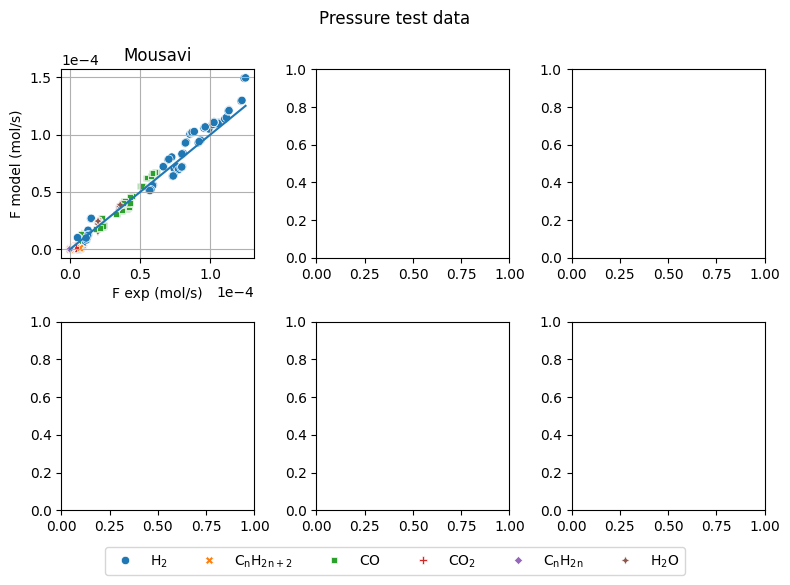

In [19]:
fig, axs = plt.subplots(2, 3, figsize = (8, 5.5))
flat_axs = axs.flatten()

max_xy = data_for_simulation.Fout_exp.max()
for i, model in enumerate(params_dict.keys()):
    sns.scatterplot(data = data_for_simulation, 
                    x = 'Fout_exp', y = f'Fout_{model}',
                    ax=flat_axs[i],
                    hue = 'leg_labels', style = 'leg_labels',
                   )
    flat_axs[i].set_title(model)
    flat_axs[i].set_ylabel('F model (mol/s)')
    flat_axs[i].set_xlabel('F exp (mol/s)')
    flat_axs[i].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
    # flat_axs[i].set_yscale('log')
    # flat_axs[i].set_xscale('log')
    flat_axs[i].plot((0, max_xy), (0, max_xy))
    flat_axs[i].grid('both')
    flat_axs[i].legend().remove()

handles, labels = flat_axs[0].get_legend_handles_labels()

fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.06), # Adjust 0.92 to move it up or down
           ncol=6, 
           frameon=True)
fig.suptitle('Pressure test data')
plt.tight_layout()
# fig_name = 'Fout_parity_training.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')

In [20]:
molar_mass_dict = {
 '$\\mathrm{H_2}$':           2,
 '$\\mathrm{CH_4}$':          16,
 '$\\mathrm{CO}$':            12+16,
 '$\\mathrm{CO_2}$':          44,
 '$\\mathrm{C_2 H_4}$':        2*12 + 4,
 '$\\mathrm{C_2 H_6}$':        2*12 + 6,
 '$\\mathrm{C_3 H_8}$':        3*12 + 8,
 '$\\mathrm{H_2 O}$':         18,
 '$\\mathrm{C_9 H_{20}}$':     9*12 + 20,
 '$\\mathrm{C_{10} H_{22}}$': 10*12 + 22,
 '$\\mathrm{C_{11} H_{24}}$': 11*12 + 24,
 '$\\mathrm{C_{12} H_{26}}$': 12*12 + 26,
 '$\\mathrm{C_{13} H_{28}}$': 13*12 + 28,
 '$\\mathrm{C_{14} H_{30}}$': 14*12 + 30,
 '$\\mathrm{C_{15} H_{32}}$': 15*12 + 32,
 '$\\mathrm{C_{16} H_{34}}$': 16*12 + 34,
 '$\\mathrm{C_{17} H_{36}}$': 17*12 + 36,
 '$\\mathrm{C_{18} H_{38}}$': 18*12 + 38,
 '$\\mathrm{C_{19} H_{40}}$': 19*12 + 40,
 '$\\mathrm{C_{20} H_{42}}$': 20*12 + 42,
 '$\\mathrm{C_{21} H_{44}}$': 21*12 + 44,
 '$\\mathrm{C_{22} H_{46}}$': 22*12 + 46,
 '$\\mathrm{C_{23} H_{48}}$': 23*12 + 48,
 '$\\mathrm{C_{24} H_{50}}$': 24*12 + 50,
 '$\\mathrm{C_{25} H_{52}}$': 25*12 + 52,
 '$\\mathrm{C_{26} H_{54}}$': 26*12 + 54,
 '$\\mathrm{C_{27} H_{56}}$': 27*12 + 56,
 '$\\mathrm{C_{28} H_{58}}$': 28*12 + 58,
 '$\\mathrm{C_{29} H_{60}}$': 29*12 + 60,
 '$\\mathrm{C_{30} H_{62}}$': 30*12 + 62,
 '$\\mathrm{C_9 H_{18}}$':     9*12 + 18,
 '$\\mathrm{C_{10} H_{20}}$': 10*12 + 20,
 '$\\mathrm{C_{11} H_{22}}$': 11*12 + 22,
 '$\\mathrm{C_{12} H_{24}}$': 12*12 + 24,
 '$\\mathrm{C_{13} H_{26}}$': 13*12 + 26,
 '$\\mathrm{C_{14} H_{28}}$': 14*12 + 28,
 '$\\mathrm{C_{15} H_{30}}$': 15*12 + 30,
 '$\\mathrm{C_{16} H_{32}}$': 16*12 + 32,
 '$\\mathrm{C_{17} H_{34}}$': 17*12 + 34,
 '$\\mathrm{C_{18} H_{36}}$': 18*12 + 36}

In [21]:
data_for_simulation['MM (g/mol)'] = data_for_simulation.component.map(molar_mass_dict)

In [22]:
data_for_simulation['m_out_exp (g/d)'] = 86400 * data_for_simulation['MM (g/mol)']*data_for_simulation.Fout_exp

In [23]:
data_for_simulation['P (bar)'] = data_for_simulation.P_abs_Pa / 1e5

In [24]:
for model in model_names:
    data_for_simulation[f'm_out_{model} (g/d)'] = (
        data_for_simulation['MM (g/mol)']*data_for_simulation[f'Fout_{model}']
    ) * 86400

In [25]:
plot_mass_flows = data_for_simulation.groupby(['index', 'leg_labels']).sum()

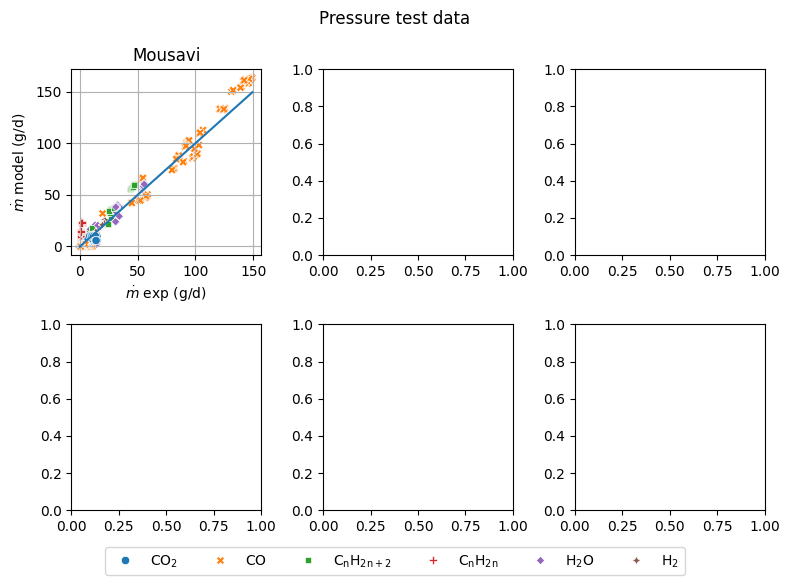

In [26]:
fig, axs = plt.subplots(2, 3, figsize = (8, 5.5))
flat_axs = axs.flatten()

max_xy = data_for_simulation['m_out_exp (g/d)'].max()
for i, model in enumerate(params_dict.keys()):
    sns.scatterplot(data = plot_mass_flows, 
                    x = 'm_out_exp (g/d)', y = f'm_out_{model} (g/d)',
                    ax=flat_axs[i],
                    hue = 'leg_labels', style = 'leg_labels',
                   )
    flat_axs[i].set_title(model)
    flat_axs[i].set_ylabel(r'$\dot{m}$ model (g/d)')
    flat_axs[i].set_xlabel(r'$\dot{m}$ exp (g/d)')
    # flat_axs[i].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
    # flat_axs[i].set_yscale('log')
    # flat_axs[i].set_xscale('log')
    flat_axs[i].plot((0, max_xy), (0, max_xy))
    flat_axs[i].grid('both')
    flat_axs[i].legend().remove()

handles, labels = flat_axs[0].get_legend_handles_labels()

fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.06), # Adjust 0.92 to move it up or down
           ncol=6, 
           frameon=True)
fig.suptitle('Pressure test data')
plt.tight_layout()
# fig_name = 'm_out_parity_training.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')

In [27]:
parametric_data_onlyP = pd.read_pickle('parametric_data/data_onlyP.pkl')

In [28]:
new_names_mapping = {
    'P_bar': 'P (bar)',
    'T_C': 'T (ºC)',
    'v_H2_in': r'$\mathrm{v_{H_2,in}}$ (mL/min)',
    'v_CO_in': r'$\mathrm{v_{CO,in}}$ (mL/min)',
    'H2_CO': r'$\mathrm{H_2/CO}$',
    'X_CO': r'$\mathrm{X_{CO}}$',
    'X_H2': r'$\mathrm{X_{H_2}}$',
    'C9_C15_sel': r'$\mathrm{Sel_{C9-C15}}$',
}

parametric_data_onlyP = parametric_data_onlyP.rename(columns=new_names_mapping)

parametric_data_onlyP[['C1-C3', 
                 'C9-C15', 
                 'C16+', 
                 r'$\mathrm{\dot{m}_{H_2O}}$ (g/d)']] = parametric_data_onlyP[['m_C1_C3', 
                                                                        'm_C9_C15', 
                                                                        'm_C16p', 
                                                                        'm_water']]*1000*60*60*24

In [29]:
comp_C_range = {'$\\mathrm{H_2}$': 'hydrogen',
 '$\\mathrm{CH_4}$': 'C1-C3',
 '$\\mathrm{CO}$': 'carbon monoxide',
 '$\\mathrm{CO_2}$': 'carbon dioxide',
 '$\\mathrm{C_2 H_4}$': 'C1-C3',
 '$\\mathrm{C_2 H_6}$': 'C1-C3',
 '$\\mathrm{C_3 H_8}$': 'C1-C3',
 '$\\mathrm{H_2 O}$': 'water',
 '$\\mathrm{C_9 H_{20}}$': 'C9-C15',
 '$\\mathrm{C_{10} H_{22}}$': 'C9-C15',
 '$\\mathrm{C_{11} H_{24}}$': 'C9-C15',
 '$\\mathrm{C_{12} H_{26}}$': 'C9-C15',
 '$\\mathrm{C_{13} H_{28}}$': 'C9-C15',
 '$\\mathrm{C_{14} H_{30}}$': 'C9-C15',
 '$\\mathrm{C_{15} H_{32}}$': 'C9-C15',
 '$\\mathrm{C_{16} H_{34}}$': 'C16+',
 '$\\mathrm{C_{17} H_{36}}$': 'C16+',
 '$\\mathrm{C_{18} H_{38}}$': 'C16+',
 '$\\mathrm{C_{19} H_{40}}$': 'C16+',
 '$\\mathrm{C_{20} H_{42}}$': 'C16+',
 '$\\mathrm{C_{21} H_{44}}$': 'C16+',
 '$\\mathrm{C_{22} H_{46}}$': 'C16+',
 '$\\mathrm{C_{23} H_{48}}$': 'C16+',
 '$\\mathrm{C_{24} H_{50}}$': 'C16+',
 '$\\mathrm{C_{25} H_{52}}$': 'C16+',
 '$\\mathrm{C_{26} H_{54}}$': 'C16+',
 '$\\mathrm{C_{27} H_{56}}$': 'C16+',
 '$\\mathrm{C_{28} H_{58}}$': 'C16+',
 '$\\mathrm{C_{29} H_{60}}$': 'C16+',
 '$\\mathrm{C_{30} H_{62}}$': 'C16+',
 '$\\mathrm{C_9 H_{18}}$': 'C9-C15',
 '$\\mathrm{C_{10} H_{20}}$': 'C9-C15',
 '$\\mathrm{C_{11} H_{22}}$': 'C9-C15',
 '$\\mathrm{C_{12} H_{24}}$': 'C9-C15',
 '$\\mathrm{C_{13} H_{26}}$': 'C9-C15',
 '$\\mathrm{C_{14} H_{28}}$': 'C9-C15',
 '$\\mathrm{C_{15} H_{30}}$': 'C9-C15',
 '$\\mathrm{C_{16} H_{32}}$': 'C16+',
 '$\\mathrm{C_{17} H_{34}}$': 'C16+',
 '$\\mathrm{C_{18} H_{36}}$': 'C16+'}

data_for_simulation['C_range'] = data_for_simulation.component.map(comp_C_range)

In [30]:
plot_mass_flows = data_for_simulation.groupby(['index', 'C_range']).sum()

plot_mass_flows.P_abs_Pa = data_for_simulation.groupby(['index', 'C_range']).P_abs_Pa.mean()
plot_mass_flows.T_R_K = data_for_simulation.groupby(['index', 'C_range']).T_R_K.mean()
plot_mass_flows.H2_CO = data_for_simulation.groupby(['index', 'C_range']).H2_CO.mean()

plot_mass_flows['P (bar)'] = plot_mass_flows.P_abs_Pa / 1e5
plot_mass_flows['T (ºC)'] = plot_mass_flows.T_R_K - 273.15

In [31]:
plot_mass_flows.xs('C9-C15', level='C_range')[['P (bar)', 'T (ºC)', 'm_out_exp (g/d)', 'm_out_Mousavi (g/d)']]

,P (bar),T (ºC),m_out_exp (g/d),m_out_Mousavi (g/d)
index,,,,
45,22.471562,233.0,2.699199,10.366535
46,22.402614,233.0,2.607497,10.378509
47,22.333667,233.0,2.661656,10.375550
48,22.333667,233.0,2.634466,10.364488
54,21.919981,222.0,2.905286,2.888535
...,...,...,...,...
289,21.506296,271.0,22.376003,51.137547
302,41.638986,271.0,10.200155,31.867177
303,41.638986,271.0,9.857409,33.176949


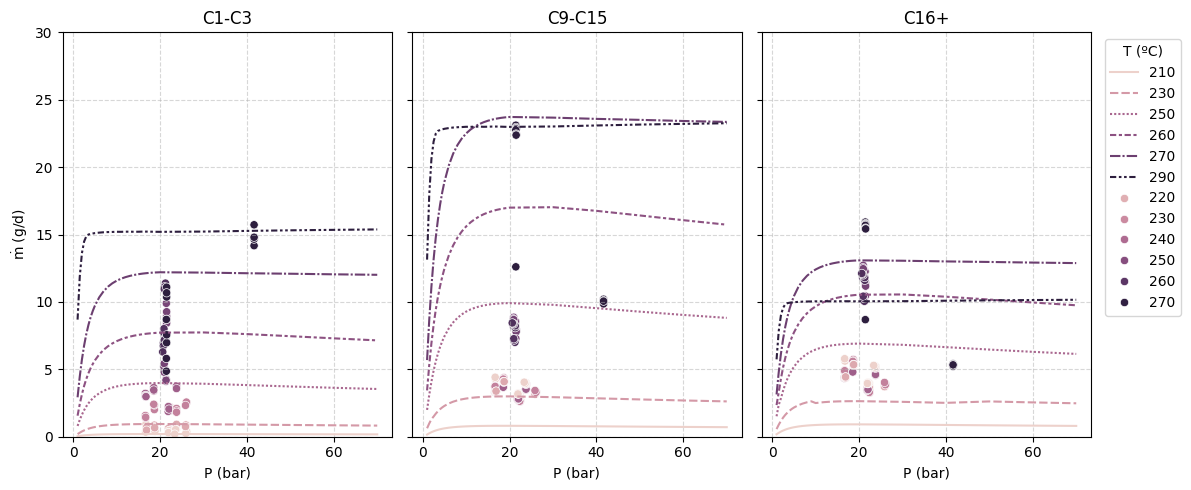

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the columns (carbon fractions) to iterate over
fractions = ['C1-C3', 'C9-C15', 'C16+']

# Initialize subplots
fig, ax = plt.subplots(1, 3, figsize=(12, 5), sharey=True)

for i, col in enumerate(fractions):
    # Melt only the necessary columns for the current subplot
    data_melted = parametric_data_onlyP[['P (bar)', 'T (ºC)', col]].melt(
        id_vars=['P (bar)', 'T (ºC)']
    )

    data_exp = plot_mass_flows.xs(col, level='C_range')[['P (bar)', 'T (ºC)', 'm_out_exp (g/d)']]
    
    # Plotting
    sns.lineplot(
        data=data_melted,
        x='P (bar)',
        y='value',
        hue='T (ºC)',
        style='T (ºC)',
        ax=ax[i],
        legend=(i == 2) # Show legend only on the last plot to save space
    )

    sns.scatterplot(
        data=data_exp,
        x='P (bar)',
        y='m_out_exp (g/d)',
        hue='T (ºC)',
        ax=ax[i],
        legend=(i == 2) # Show legend only on the last plot to save space
    )
    
    # Formatting each subplot
    ax[i].set_title(col)
    # ax[i].set_xlim(0,10)
    ax[i].set_ylim(0,30)
    ax[i].grid(True, which='both', linestyle='--', alpha=0.5)
    ax[i].set_ylabel(r'$\mathrm{\dot{m}}$ (g/d)' if i == 0 else "")

# Adjust legend position on the last axis
ax[2].legend(bbox_to_anchor=(1.02, 1), title='T (ºC)', loc='upper left')

plt.tight_layout()

# Save logic
# fig_name = 'parametric_study_P.pdf'
# save_path = f'Z:\\uem\\Doutorado\\Papers\\SAF_kinetics\\figures\\{fig_name}'
# plt.savefig(save_path, bbox_inches='tight')
plt.show()

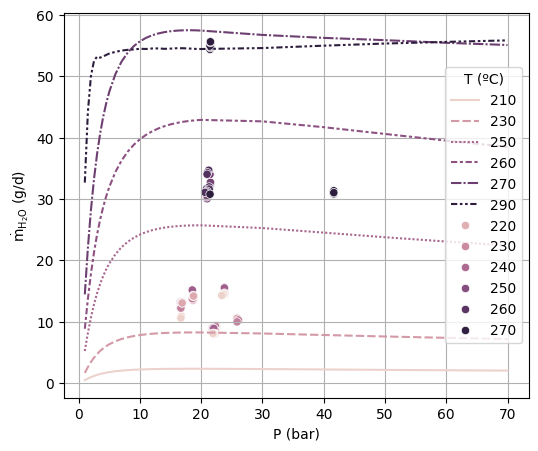

In [33]:
fig, ax = plt.subplots(figsize = (6,5))

sns.lineplot(data = parametric_data_onlyP, x = 'P (bar)', y = r'$\mathrm{\dot{m}_{H_2O}}$ (g/d)', style = 'T (ºC)', hue = 'T (ºC)')
sns.scatterplot(
        data=plot_mass_flows.xs('water', level='C_range')[['P (bar)', 'T (ºC)', 'm_out_exp (g/d)']],
        x='P (bar)',
        y='m_out_exp (g/d)',
        hue='T (ºC)',
        ax=ax,
    )
plt.grid('both')
# plt.xlim(0,10)